In [13]:
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle 

In [15]:
df = pd.read_csv('demand_dataset.csv')
print(df.value_counts())

hour_of_day  day_of_week  temperature_celsius  demand_level
4            0            15.3                 0               2
2            4            34.8                 0               2
3            2            18.0                 0               2
20           6            12.4                 2               2
9            3            37.5                 0               2
                                                              ..
7            4            17.6                 0               1
                          24.3                 1               1
             5            11.8                 1               1
                          12.0                 1               1
23           6            43.9                 1               1
Name: count, Length: 795, dtype: int64


In [16]:
#Features nd target split 
X = df[["hour_of_day", "day_of_week", "temperature_celsius"]].values
y = df["demand_level"].values



In [17]:
#one-hot encode for target 
y_cat = to_categorical(y,num_classes=3)
y_cat

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]], shape=(800, 3))

In [18]:
#train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

In [19]:
#scaler 

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[-0.04542971,  1.00635595, -0.92906286],
       [-0.59923956,  1.50179272, -0.06360281],
       [ 0.36992767, -0.97539115, -0.50119497],
       ...,
       [-0.59923956,  0.51091917, -0.95823567],
       [ 0.50838013,  0.0154824 , -0.2289154 ],
       [ 0.78528505,  1.50179272, -1.10409973]], shape=(640, 3))

In [20]:
#model 

model = Sequential([
    Dense(64 , activation="relu" , input_shape=(3,)),
    Dropout(0.3),
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(3,activation="softmax")
]
)

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435 (9.51 KB)

 Trainable params: 2,435 (9.51 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#compile nd train 

model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=2,
)

Epoch 1/100
16/16 - 1s - 50ms/step - accuracy: 0.5430 - loss: 0.8668 - val_accuracy: 0.5781 - val_loss: 0.7966
Epoch 2/100
16/16 - 0s - 3ms/step - accuracy: 0.5547 - loss: 0.8754 - val_accuracy: 0.5625 - val_loss: 0.8014
Epoch 3/100
16/16 - 0s - 3ms/step - accuracy: 0.5703 - loss: 0.8886 - val_accuracy: 0.5703 - val_loss: 0.8073
Epoch 4/100
16/16 - 0s - 3ms/step - accuracy: 0.5820 - loss: 0.8783 - val_accuracy: 0.5781 - val_loss: 0.8037
Epoch 5/100
16/16 - 0s - 3ms/step - accuracy: 0.5527 - loss: 0.8542 - val_accuracy: 0.5703 - val_loss: 0.7994
Epoch 6/100
16/16 - 0s - 3ms/step - accuracy: 0.5605 - loss: 0.8717 - val_accuracy: 0.5547 - val_loss: 0.7973
Epoch 7/100
16/16 - 0s - 3ms/step - accuracy: 0.5605 - loss: 0.8552 - val_accuracy: 0.5625 - val_loss: 0.7930
Epoch 8/100
16/16 - 0s - 3ms/step - accuracy: 0.5605 - loss: 0.8546 - val_accuracy: 0.5547 - val_loss: 0.7890
Epoch 9/100
16/16 - 0s - 3ms/step - accuracy: 0.5723 - loss: 0.8733 - val_accuracy: 0.5469 - val_loss: 0.8018
Epoch 10/

In [ ]:
with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)




Final Test Accuracy: 58.75%
Final Test Loss: 0.7668


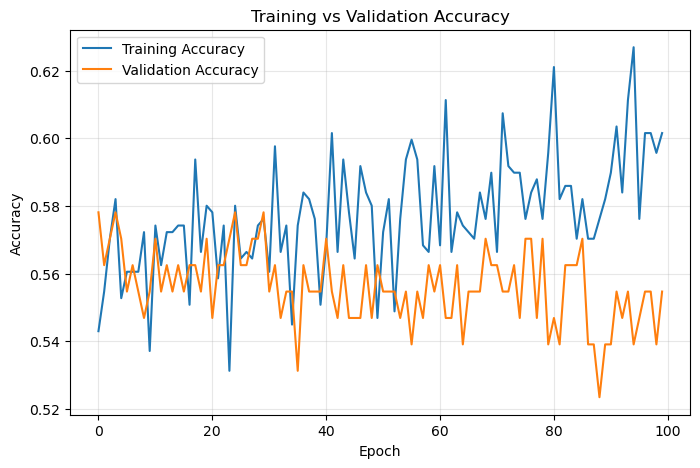


Model saved as demand_model.keras


In [27]:
#Evaluate nd plot 
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("accuracy_plot.png", dpi=150, bbox_inches="tight")
plt.show()

model.save("demand_model.keras")
print("\nModel saved as demand_model.keras")


In [28]:
model.save("demand_model.keras")